In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API key is set")
else:
    raise ValueError("Google API key is not set")

Google API key is set


In [2]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
   # other params...
)

try :
  print("Dont waste Tokens")
 # print(model.invoke("I want to know about Langgraph ?"))
except:
  print("Something went wrong")

Dont waste Tokens


### TOOLS

In [3]:
from langchain.tools import tool # This package is required for creating a custom tool
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def search_duckduckgo(query: str) -> str:
    """This tool Searches the latest news on DuckDuckGo for the given query. and returns the results"""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)


/tmp/ipykernel_386/4206626559.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


### Wikipedia Search Tool

In [4]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query : str)->str :
    """This tool allows you to search Wikipedia for information on a given topic"""
    wikipedia_query=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wikipedia_query.invoke(query)



### Custom Tool

In [5]:
@tool #Decorator to say that below function is a tool
def personal_info(name: str):
    """ Use this tool to get personal information about Alice, Bob or Charlie."""
    # Doc strings are important in tools as LLM gets contect of the tool 
    info={
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "I don't know about that person.")

### TOOL BINDING

In [6]:
tools=[search_duckduckgo,wiki_tool,personal_info]

llm_with_tools = model.bind_tools(tools)

In [7]:
llm_with_tools.invoke("What is the latest news on AWS")

AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "AWS news"}'}, '__gemini_function_call_thought_signatures__': {'25db973f-4a07-4d42-a7dd-b7a38c5f4983': 'CuMBARFNMg9lbOM36uoKUtb9YalvAu+NbIuwlFoQ5avH+6B88WsrrSugQRK0CJ7CpxKpaPQrBY+PhTnqUwHWlnoHEcy0Wr37ZHRlJcYPT19VMv3VYgr8WiT8E2KUJzJmPyVYU3PAvjwHCOTfrrTvqgMTLclwDGYo/RC3ar/76ditaq3oiuYorb7kKt7GZi6Tk/sBjhJXaAD7TGMMNiWp4NPCwStqBCKNHvnqBOOLrq26yJcdleJi7qLsgAg5Cbga5NQZoI+b3V3bX2n3+PsMGfeiB1G5D3HXYYXz6rgX+pRy8lZ9bss='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f588b-a018-71f3-984a-787cca832eb6-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'AWS news'}, 'id': '25db973f-4a07-4d42-a7dd-b7a38c5f4983', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 152, 'output_tokens': 66, 'total_tokens': 218, 'input_token_details': {'cache_read': 0

### LangGraph Creation

### Create Schema

In [8]:
from typing import TypedDict,List

class graph_schema(TypedDict):
    messages: List

### Create Node Functions

In [11]:
from langchain_core.prompts import ChatPromptTemplate

def llm_node(state: graph_schema) -> graph_schema:
    messages = state['messages']
    # Prompt Template for the LLM, including System and Human Input
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

# LLM with Tools
#llm_with_tools

    chain= prompt | llm_with_tools

    response = chain.invoke({"input": messages})

    state['messages']= messages + [response]

    return state
#


In [24]:
# We have a prebuilt ToolNode by Langgraph but we are building our own tool node for customizations
# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema) -> graph_schema:
    messages=state['messages']
    tools_by_name={tool.name:tool for tool in tools}
    tool_results=[]
    for tool_call in messages[-1].tool_calls:
        tool=tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])#These arguments are provided by LLM, but it couldnot invoke the tools. It fetches the arguments by looking at the function code and docstrings.
        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    
    state['messages']=messages+tool_results
    return state
        


### Create Conditional Edge Function

Conditional Edges in Langgraphs are edges in Langgraph, that are called when a condition is satisfied. Lets say we have a tool to search the weather. To check the weather, we need to make a tool call. My input is what is LLM(answered by LLM) and say about todays weather(tool call). So with regular graph edges everything will be deterministic(START->LLMNODE->TOOLNODE->END) but in this case if there is no check weather part, then making a toolnode call is irrelavant, to overcome this we have conditional edge functions.

In [25]:
def if_tool_call(state:graph_schema)->str:
    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

### Create State Graph

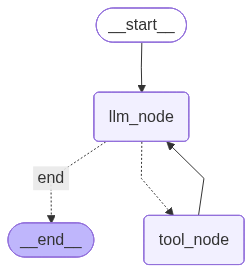

In [26]:
from langgraph.graph import StateGraph, START, END

graph=StateGraph(graph_schema)

#Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node",tool_node)

#Add Edges between Nodes
graph.add_edge(START,"llm_node")
graph.add_conditional_edges("llm_node",if_tool_call,{"tool_node":"tool_node","end":END}) # add_conditional_edges("NodeCurrent",NodeConditionCheckFunction that return "NextNode")
graph.add_edge("tool_node","llm_node")#if_tool_call return ToolNode, LLM_NODE goes to TOOL_NODE, again it should comeback to LLM_NODE, so this edges give it.
graph.add_edge("llm_node",END)

ReAct_graph=graph.compile()

from IPython.display import Image, display

Image(ReAct_graph.get_graph().draw_mermaid_png())

### Graph Invocation

In [27]:
ReAct_graph.invoke({"messages":[HumanMessage(content="What is the latest news on the Indian stock market?")]})

{'messages': [HumanMessage(content='What is the latest news on the Indian stock market?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "Indian stock market news"}'}, '__gemini_function_call_thought_signatures__': {'7dfc8aa6-feac-4b62-9eb5-723f17f559e1': 'CrsCARFNMg/keMof8MPcN80P1sz6HTTCezd4l3nPHplCRUJirsYITobApitkNAqm8vgCpi5q5Kc61YoJlBVJQUkHoX2FYXKIWbLHLhhQCQkaOxmNW+Lq5b97luz+CZOp9RHC9vIsewOybEePqLYiQ5h4AnUugYhgOtyZBbFctCaXsZR91m+e9xUzrQOQNdI+E2lUQwmF8ijbeKvkkS2cJFhE0TFm6F2rEE6KXupZwtY+6mR3UjOLcTkpk6HA/tQS8uJGoh7+cI7YpyrtB9f3zaSWlX5WQgzi7/cSDL2G7FxoGbqx4OIOCLcBdY/Gsx2GoqQXGZmo5ThJWfCAl8diNm7p3j+ja14enkuGdukvwElw/ms/DhisIuu9dig4Lrc3eDuchMdzjWQ+VL/g7ameOoxxeEHYK7JqKd+uGHzU'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f58ab-5c3d-7ca2-a8b8-3ba5ec1e8693-0', tool_calls=[{'

In [28]:
# To stream the output
for chunk in ReAct_graph.stream(
    {"messages":[HumanMessage(content="What is the latest news on the Indian stock market?")]},
    stream_mode='updates'
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='What is the latest news on the Indian stock market?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "latest news Indian stock market"}'}, '__gemini_function_call_thought_signatures__': {'bd88938b-d80b-4eb0-9920-a898ce477e49': 'CqICARFNMg9h9aTvVouKfUUHIRrm85otZV33WMooRaEutSxqfwFarNpHSlEhBOO5p7I0lWwOji6Ikf3TmbqYjz5t3quUEa159XDl7w6qqRKMxCc6fLFLldVVACMLCVYP85bWQKlZ3r1eZb5NPhjfLktEAfR2Ebh/+rs+R4DWQKSSV8lZSST63iASKLzI+DBArPl8AEDmwVPiOlqoSCfVYBk/QiP+IfmLhW4XUpEb/OFGPtRCNUkYlFLA9DwZ0aTvb8tlasillIyVNqXlcIa0SohD22cqWy1EMZRRyOhIOF52c8SaVkd45+hKuVbUg6hAuugl9fuO8QVnK4Xlsb60H4qFC3SeKkkGSp7jCssJdds+RetbZ60/IiBfdEnRaux+IroC3no='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f58ae-90f1-7532-ad88-3b43b3c83900-0', tool_calls=[{'name': 'search